# Redes Neuronales+ SMOTE 

## I. Librerías

In [ ]:
import numpy as np
import pandas as pd
import glob
import warnings
from sklearn import preprocessing

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RepeatedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE
from collections import Counter

warnings.filterwarnings('ignore')

from scipy.stats import loguniform


## Data Loading

In [ ]:
import os
DATASETS = glob.glob(os.path.join("dataset", "*.csv"))
print(DATASETS) 


dfs = [pd.read_csv(path) for path in DATASETS]
df = pd.concat(dfs, ignore_index=True)

['C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Tuesday-WorkingHours.pcap_ISCX.csv']


## Clean Data

In [ ]:
# Remove leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

# Separate features and target
X = df.drop('Label', axis=1)
y = df['Label']

# Replace infinite values with NaN, then drop affected rows
X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]


## Train / Test Split + Normalization

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=1234, shuffle=True, stratify=y
)

scaler = preprocessing.MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X.columns)


## SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from collections import Counter

# ==============================
# BEFORE SMOTE
# ==============================
print('Before Over Sampling:')
print(Counter(y_train))
print()

# ==============================
# CREATE SAMPLING STRATEGY
# ==============================
cap = 10000  # maximum samples per minority class after oversampling

counts = Counter(y_train)

# Only oversample classes that fall below the cap
sampling_dict = {cls: cap for cls, c in counts.items() if c < cap}

print('Sampling strategy:', sampling_dict)
print()

# ==============================
# APPLY SMOTE
# ==============================
sm1 = SMOTE(
    sampling_strategy=sampling_dict,
    random_state=2,
    k_neighbors=3  # conservative choice: some minority classes have very few samples
)

X_train_res, y_train_res = sm1.fit_resample(X_train, y_train.to_numpy())

# ==============================
# AFTER SMOTE
# ==============================
print('After Over Sampling:')
print(Counter(y_train_res))
print()

print('After Over Sampling, the shape of train_X:', X_train_res.shape)
print('After Over Sampling, the shape of train_y:', y_train_res.shape)


Before Over Sampling:
Counter({'BENIGN': 1041725, 'PortScan': 127043, 'DDoS': 102420, 'FTP-Patator': 6348, 'SSH-Patator': 4717, 'Bot': 1565, 'Web Attack � Brute Force': 1205, 'Web Attack � XSS': 522, 'Infiltration': 29, 'Web Attack � Sql Injection': 17})

Sampling strategy: {'FTP-Patator': 10000, 'SSH-Patator': 10000, 'Web Attack � Brute Force': 10000, 'Bot': 10000, 'Web Attack � XSS': 10000, 'Web Attack � Sql Injection': 10000, 'Infiltration': 10000}

After Over Sampling:
Counter({'BENIGN': 1041725, 'PortScan': 127043, 'DDoS': 102420, 'FTP-Patator': 10000, 'SSH-Patator': 10000, 'Web Attack � Brute Force': 10000, 'Bot': 10000, 'Web Attack � XSS': 10000, 'Web Attack � Sql Injection': 10000, 'Infiltration': 10000})

After Over Sampling, the shape of train_X: (1341188, 78)
After Over Sampling, the shape of train_y: (1341188,)


## Subsampling for Hyperparameter Search

In [ ]:
X_train_s, _, y_train_s, _ = train_test_split(
    X_train_res, y_train_res, train_size=10000, stratify=y_train_res, random_state=42
)
print('Subsample shape:', X_train_s.shape)
print(pd.Series(y_train_s).value_counts())


Subsample shape: (10000, 78)
BENIGN                        7767
PortScan                       947
DDoS                           764
FTP-Patator                     75
Bot                             75
Infiltration                    75
Web Attack � Sql Injection      75
SSH-Patator                     74
Web Attack � Brute Force        74
Web Attack � XSS                74
Name: count, dtype: int64


## Hyperparameter Search

**Round 1** — big exploration across architectures and learning rates.

In [ ]:
param_distributions1 = {
    'hidden_layer_sizes': [(50,), (100,), (50, 20), (100, 50)],
    'learning_rate_init': loguniform(1e-4, 1e-1)
}


In [ ]:
grid = RandomizedSearchCV(
    estimator=MLPClassifier(
        solver='adam',
        max_iter=200,
        activation='relu',
        random_state=123
    ),
    param_distributions=param_distributions1,
    n_iter=8,
    scoring='f1_macro',
    cv=2,
    verbose=3,
    random_state=123,
    return_train_score=True,
    n_jobs=1
)

grid.fit(X_train_s, y_train_s)

results = pd.DataFrame(grid.cv_results_)
cols = ['param_hidden_layer_sizes',
        'param_learning_rate_init',
        'mean_test_score',
        'std_test_score',
        'mean_train_score',
        'rank_test_score']
print('\n===== RESULTS BY COMBINATION =====')
display(
    results[cols]
    .sort_values('mean_test_score', ascending=False)
    .reset_index(drop=True)
    .round(4)
)
print('\nBest params:', grid.best_params_)
print('Best F1 (cv):', round(grid.best_score_, 4))


Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV 1/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.013767844795855265;, score=(train=0.740, test=0.714) total time=   1.9s
[CV 2/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.013767844795855265;, score=(train=0.750, test=0.726) total time=   1.8s
[CV 1/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.0004792414358623592;, score=(train=0.592, test=0.561) total time=   4.4s
[CV 2/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.0004792414358623592;, score=(train=0.552, test=0.534) total time=   4.5s
[CV 1/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.014369806843613596;, score=(train=0.768, test=0.730) total time=   1.3s
[CV 2/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.014369806843613596;, score=(train=0.752, test=0.732) total time=   2.4s
[CV 1/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.0018591711878786364;, score=(train=0.822, test=0.768) total time=

,param_hidden_layer_sizes,param_learning_rate_init,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,"(50, 20)",0.0019,0.7657,0.0021,0.7964,1
1,"(50,)",0.0154,0.7497,0.0032,0.7902,2
2,"(50, 20)",0.0017,0.7485,0.0254,0.7847,3
3,"(50, 20)",0.0144,0.7309,0.0011,0.7598,4
4,"(100,)",0.0016,0.7281,0.0327,0.7674,5
5,"(100,)",0.0028,0.7232,0.0253,0.7677,6
6,"(50, 20)",0.0138,0.7200,0.0058,0.7447,7
7,"(50, 20)",0.0005,0.5475,0.0139,0.5721,8



Best params: {'hidden_layer_sizes': (50, 20), 'learning_rate_init': np.float64(0.0018591711878786364)}
Best F1 (cv): 0.7657


**Round 2** — refine architectures and learning rates.

In [ ]:
param_distributions2 = {
    'hidden_layer_sizes': [(100,), (80,), (80, 20), (40, 20), (50, 20)],
    'learning_rate_init': [0.0008, 0.001, 0.0015, 0.0018, 0.002, 0.0025]
}


In [ ]:
grid = RandomizedSearchCV(
    estimator=MLPClassifier(
        solver='adam',
        max_iter=200,
        activation='relu',
        random_state=123
    ),
    param_distributions=param_distributions2,
    n_iter=8,
    scoring='f1_macro',
    cv=2,
    verbose=3,
    random_state=123,
    return_train_score=True,
    n_jobs=1
)

grid.fit(X_train_s, y_train_s)

results = pd.DataFrame(grid.cv_results_)
cols = ['param_hidden_layer_sizes',
        'param_learning_rate_init',
        'mean_test_score',
        'std_test_score',
        'mean_train_score',
        'rank_test_score']
print('\n===== RESULTS BY COMBINATION =====')
display(
    results[cols]
    .sort_values('mean_test_score', ascending=False)
    .reset_index(drop=True)
    .round(4)
)
print('\nBest params:', grid.best_params_)
print('Best F1 (cv):', round(grid.best_score_, 4))


Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV 1/2] END hidden_layer_sizes=(80,), learning_rate_init=0.001;, score=(train=0.676, test=0.653) total time=   4.4s
[CV 2/2] END hidden_layer_sizes=(80,), learning_rate_init=0.001;, score=(train=0.680, test=0.672) total time=   4.2s
[CV 1/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.0025;, score=(train=0.769, test=0.725) total time=   4.2s
[CV 2/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.0025;, score=(train=0.743, test=0.698) total time=   3.8s
[CV 1/2] END hidden_layer_sizes=(100,), learning_rate_init=0.0025;, score=(train=0.812, test=0.758) total time=   4.9s
[CV 2/2] END hidden_layer_sizes=(100,), learning_rate_init=0.0025;, score=(train=0.738, test=0.701) total time=   4.7s
[CV 1/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.0015;, score=(train=0.746, test=0.729) total time=   4.5s
[CV 2/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.0015;, score=(train=0.751, test=0.685) tot

,param_hidden_layer_sizes,param_learning_rate_init,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,"(40, 20)",0.0018,0.7498,0.0112,0.7783,1
1,"(100,)",0.0025,0.7300,0.0285,0.7752,2
2,"(50, 20)",0.0018,0.7174,0.0180,0.7591,3
3,"(50, 20)",0.0025,0.7119,0.0135,0.7561,4
4,"(80,)",0.0015,0.7079,0.0284,0.7289,5
5,"(50, 20)",0.0015,0.7066,0.0221,0.7484,6
6,"(80, 20)",0.0008,0.6846,0.0360,0.7072,7
7,"(80,)",0.0010,0.6627,0.0095,0.6779,8



Best params: {'learning_rate_init': 0.0018, 'hidden_layer_sizes': (40, 20)}
Best F1 (cv): 0.7498


**Round 3** — narrow research

In [ ]:
param_distributions3 = {
    'hidden_layer_sizes': [(50, 20), (40, 20), (60, 30)],
    'learning_rate_init': [0.0015, 0.0017, 0.0018, 0.002]
}


In [ ]:
grid = RandomizedSearchCV(
    estimator=MLPClassifier(
        solver='adam',
        max_iter=200,
        activation='relu',
        random_state=123
    ),
    param_distributions=param_distributions3,
    n_iter=8,
    scoring='f1_macro',
    cv=2,
    verbose=3,
    random_state=123,
    return_train_score=True,
    n_jobs=1
)

grid.fit(X_train_s, y_train_s)

results = pd.DataFrame(grid.cv_results_)
cols = ['param_hidden_layer_sizes',
        'param_learning_rate_init',
        'mean_test_score',
        'std_test_score',
        'mean_train_score',
        'rank_test_score']
print('\n===== RESULTS BY COMBINATION =====')
display(
    results[cols]
    .sort_values('mean_test_score', ascending=False)
    .reset_index(drop=True)
    .round(4)
)
print('\nBest params:', grid.best_params_)
print('Best F1 (cv):', round(grid.best_score_, 4))


Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV 1/2] END hidden_layer_sizes=(40, 20), learning_rate_init=0.0017;, score=(train=0.811, test=0.765) total time=   2.9s
[CV 2/2] END hidden_layer_sizes=(40, 20), learning_rate_init=0.0017;, score=(train=0.733, test=0.708) total time=   3.0s
[CV 1/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.0015;, score=(train=0.746, test=0.729) total time=   3.2s
[CV 2/2] END hidden_layer_sizes=(50, 20), learning_rate_init=0.0015;, score=(train=0.751, test=0.685) total time=   3.1s
[CV 1/2] END hidden_layer_sizes=(40, 20), learning_rate_init=0.0015;, score=(train=0.819, test=0.760) total time=   3.0s
[CV 2/2] END hidden_layer_sizes=(40, 20), learning_rate_init=0.0015;, score=(train=0.670, test=0.637) total time=   3.0s
[CV 1/2] END hidden_layer_sizes=(60, 30), learning_rate_init=0.0017;, score=(train=0.773, test=0.729) total time=   3.9s
[CV 2/2] END hidden_layer_sizes=(60, 30), learning_rate_init=0.0017;, score=(train=0.747, tes

,param_hidden_layer_sizes,param_learning_rate_init,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,"(40, 20)",0.0017,0.7364,0.0288,0.7718,1
1,"(50, 20)",0.0020,0.7336,0.0435,0.7796,2
2,"(40, 20)",0.0020,0.7242,0.0177,0.7628,3
3,"(60, 30)",0.0017,0.7155,0.0135,0.7599,4
4,"(60, 30)",0.0018,0.7116,0.0170,0.7481,5
5,"(50, 20)",0.0015,0.7066,0.0221,0.7484,6
6,"(40, 20)",0.0015,0.6986,0.0612,0.7449,7
7,"(60, 30)",0.0015,0.6842,0.0421,0.7169,8



Best params: {'learning_rate_init': 0.0017, 'hidden_layer_sizes': (40, 20)}
Best F1 (cv): 0.7364


Intermediate results: `hidden_layer_sizes=(40, 20)`, `learning_rate_init=0.0017`. Running one more round to confirm.

**FINAL Round 1** — final exploration across architectures and learning rates.

In [ ]:
param_distributions4 = {
    'hidden_layer_sizes': [(40, 20), (35, 20), (45, 20), (40, 15)],
    'learning_rate_init': [0.0016, 0.0017, 0.0018]
}


In [ ]:
grid = RandomizedSearchCV(
    estimator=MLPClassifier(
        solver='adam',
        max_iter=200,
        activation='relu',
        random_state=123
    ),
    param_distributions=param_distributions4,
    n_iter=8,
    scoring='f1_macro',
    cv=2,
    verbose=3,
    random_state=123,
    return_train_score=True,
    n_jobs=1
)

grid.fit(X_train_s, y_train_s)

results = pd.DataFrame(grid.cv_results_)
cols = ['param_hidden_layer_sizes',
        'param_learning_rate_init',
        'mean_test_score',
        'std_test_score',
        'mean_train_score',
        'rank_test_score']
print('\n===== RESULTS BY COMBINATION =====')
display(
    results[cols]
    .sort_values('mean_test_score', ascending=False)
    .reset_index(drop=True)
    .round(4)
)
print('\nBest params:', grid.best_params_)
print('Best F1 (cv):', round(grid.best_score_, 4))


Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV 1/2] END hidden_layer_sizes=(35, 20), learning_rate_init=0.0018;, score=(train=0.748, test=0.724) total time=   3.9s
[CV 2/2] END hidden_layer_sizes=(35, 20), learning_rate_init=0.0018;, score=(train=0.677, test=0.629) total time=   4.5s
[CV 1/2] END hidden_layer_sizes=(40, 20), learning_rate_init=0.0016;, score=(train=0.742, test=0.724) total time=   3.0s
[CV 2/2] END hidden_layer_sizes=(40, 20), learning_rate_init=0.0016;, score=(train=0.673, test=0.634) total time=   3.9s
[CV 1/2] END hidden_layer_sizes=(35, 20), learning_rate_init=0.0017;, score=(train=0.744, test=0.726) total time=   4.3s
[CV 2/2] END hidden_layer_sizes=(35, 20), learning_rate_init=0.0017;, score=(train=0.733, test=0.703) total time=   5.8s
[CV 1/2] END hidden_layer_sizes=(40, 15), learning_rate_init=0.0016;, score=(train=0.780, test=0.735) total time=   4.0s
[CV 2/2] END hidden_layer_sizes=(40, 15), learning_rate_init=0.0016;, score=(train=0.764, tes

,param_hidden_layer_sizes,param_learning_rate_init,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,"(40, 15)",0.0016,0.7311,0.0043,0.7718,1
1,"(40, 15)",0.0017,0.7188,0.0195,0.7713,2
2,"(35, 20)",0.0017,0.7146,0.0116,0.7388,3
3,"(45, 20)",0.0018,0.6968,0.0123,0.7447,4
4,"(45, 20)",0.0017,0.6959,0.0394,0.7263,5
5,"(35, 20)",0.0016,0.6836,0.0349,0.7077,6
6,"(40, 20)",0.0016,0.6790,0.0448,0.7076,7
7,"(35, 20)",0.0018,0.6767,0.0474,0.7129,8



Best params: {'learning_rate_init': 0.0016, 'hidden_layer_sizes': (40, 15)}
Best F1 (cv): 0.7311


Selected: `hidden_layer_sizes=(40, 15)`, `learning_rate_init=0.0016`.

The simpler architecture was preferred over slightly larger ones —, he performance difference was within one std across folds, and the smaller network reduces the risk of overfitting. The chosen learning rate gave stable convergence without the oscillations seen at higher values during the search.

## Model Training

In [ ]:
model_final = MLPClassifier(
    hidden_layer_sizes = (40, 15),
    learning_rate_init = 0.0016,
    activation         = 'relu',
    solver             = 'adam',
    max_iter           = 300,
    random_state       = 123
)

model_final.fit(X_train_res, y_train_res)
print('Training complete.')
print(f'Iterations: {model_final.n_iter_}')


Training complete.
Iterations: 149


## Evaluation

### Train


 Accuracy train: 97.48 %

                             precision    recall  f1-score   support

                    BENIGN       0.99      0.98      0.99   1041725
                       Bot       0.82      0.80      0.81     10000
                      DDoS       1.00      0.99      1.00    102420
               FTP-Patator       1.00      1.00      1.00     10000
              Infiltration       1.00      1.00      1.00     10000
                  PortScan       0.90      0.96      0.93    127043
               SSH-Patator       0.99      0.98      0.99     10000
  Web Attack � Brute Force       0.60      0.60      0.60     10000
Web Attack � Sql Injection       0.93      1.00      0.97     10000
          Web Attack � XSS       0.59      0.61      0.60     10000

                  accuracy                           0.97   1341188
                 macro avg       0.88      0.89      0.89   1341188
              weighted avg       0.98      0.97      0.98   1341188



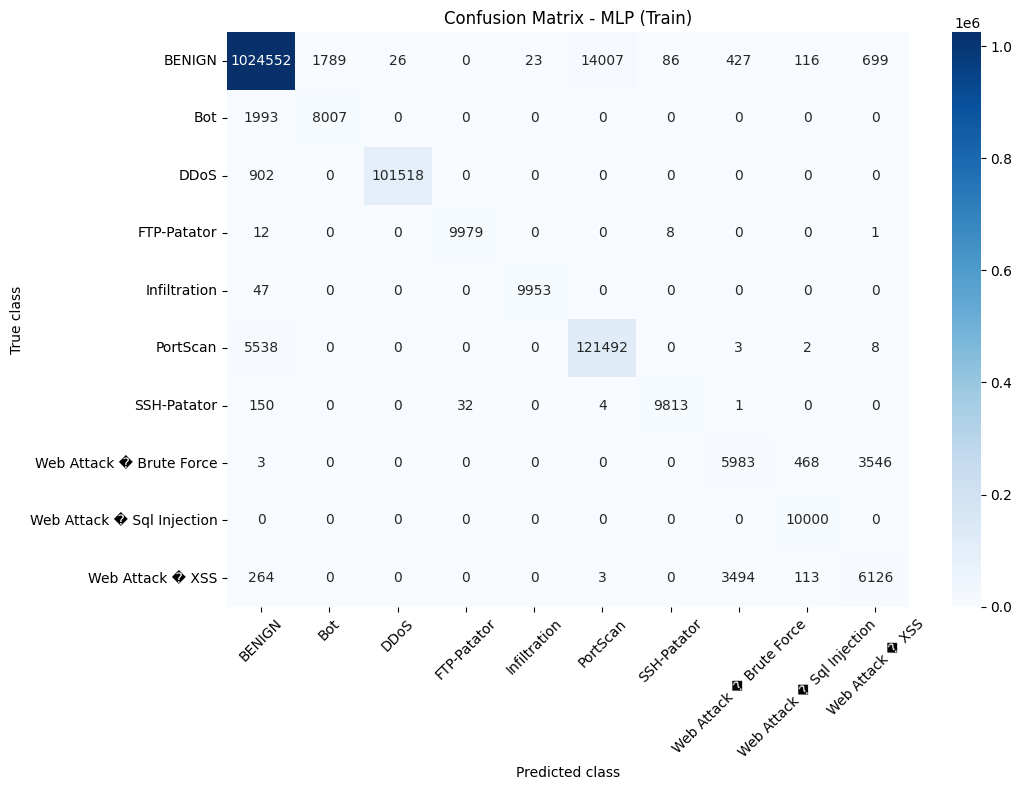

In [ ]:
predictions_train = model_final.predict(X_train_res)

print('\n Accuracy train: {:.2f} %'.format(100 * accuracy_score(y_train_res, predictions_train)))
print('\n', classification_report(y_train_res, predictions_train))

# Confusion matrix
labels = sorted(np.unique(y_train_res))
cm = confusion_matrix(y_train_res, predictions_train, labels=labels)

plt.figure(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted class'); plt.ylabel('True class')
plt.title('Confusion Matrix - MLP (Train)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


### Test

Accuracy test: 98.08 %

                             precision    recall  f1-score   support

                    BENIGN       0.99      0.98      0.99    260431
                       Bot       0.40      0.78      0.53       391
                      DDoS       1.00      0.99      1.00     25605
               FTP-Patator       1.00      1.00      1.00      1587
              Infiltration       0.50      0.71      0.59         7
                  PortScan       0.90      0.96      0.93     31761
               SSH-Patator       0.98      0.98      0.98      1180
  Web Attack � Brute Force       0.54      0.56      0.55       302
Web Attack � Sql Injection       0.05      0.75      0.10         4
          Web Attack � XSS       0.22      0.65      0.33       130

                  accuracy                           0.98    321398
                 macro avg       0.66      0.84      0.70    321398
              weighted avg       0.98      0.98      0.98    321398



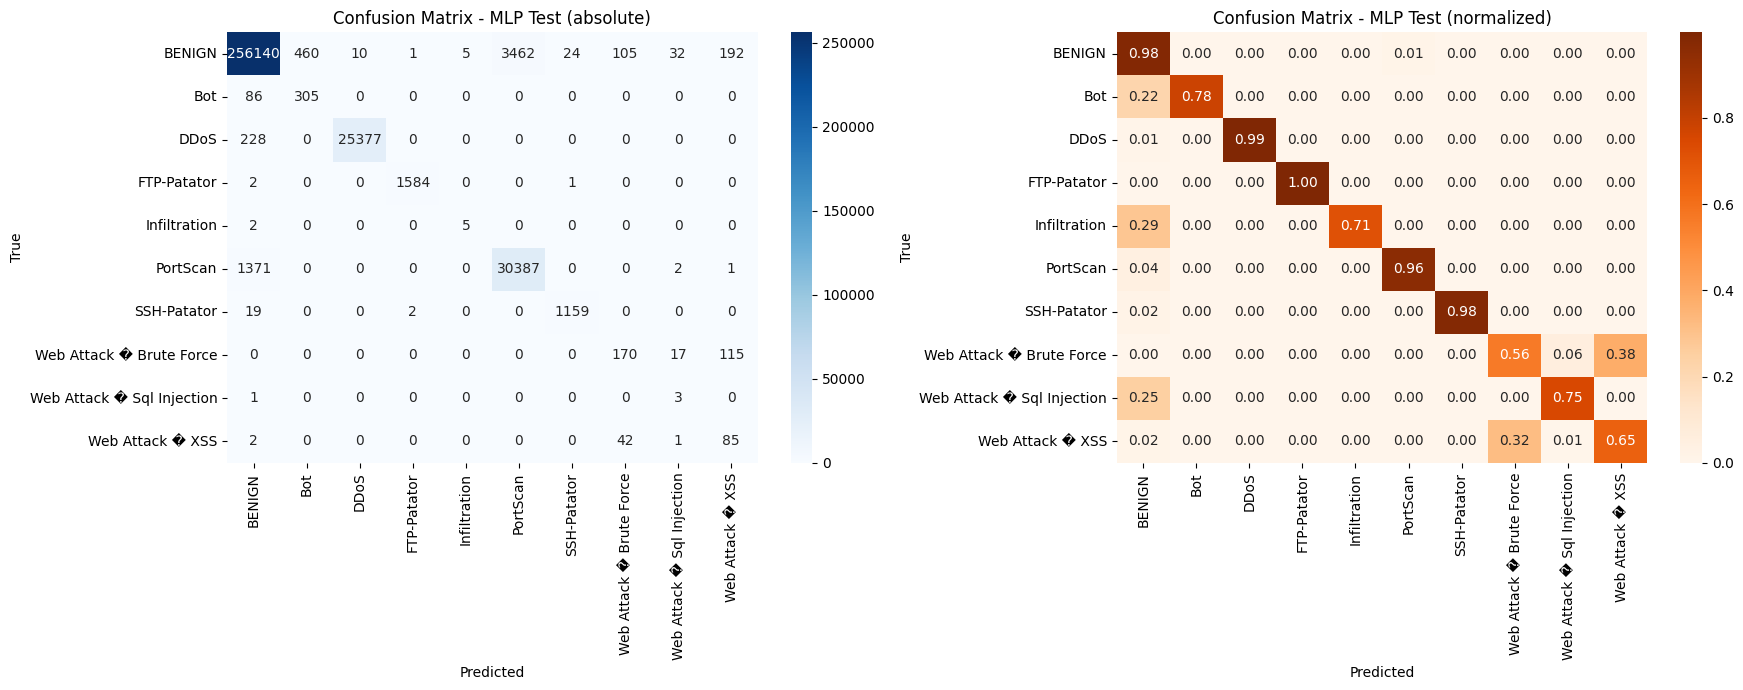

In [ ]:
pred_test = model_final.predict(X_test)

print('Accuracy test: {:.2f} %'.format(100 * accuracy_score(y_test, pred_test)))
print('\n', classification_report(y_test, pred_test))

labels = sorted(np.unique(y_test))
cm = confusion_matrix(y_test, pred_test, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix - MLP Test (absolute)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Confusion Matrix - MLP Test (normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout(); plt.show()


## Feature Importance

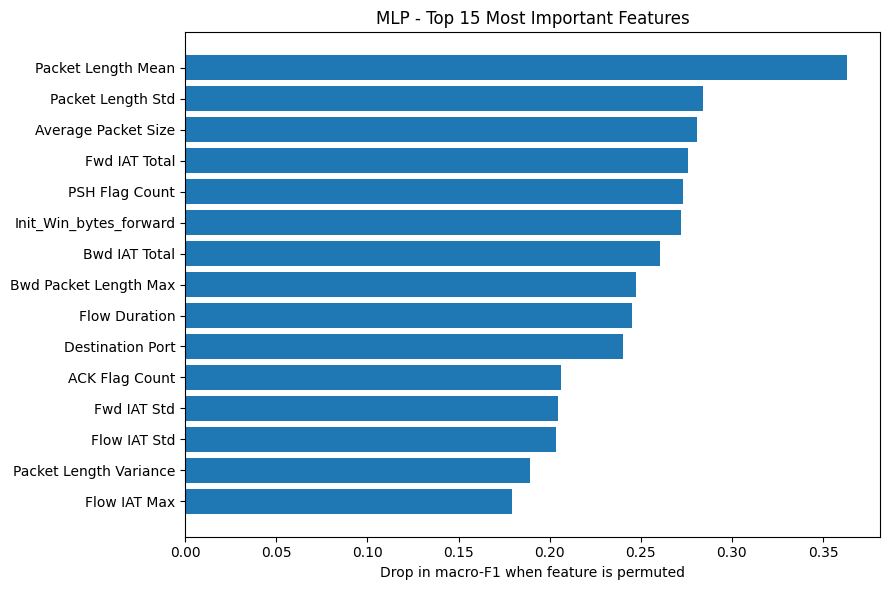

               Feature  Importance
    Packet Length Mean    0.363092
     Packet Length Std    0.284406
   Average Packet Size    0.280657
         Fwd IAT Total    0.276118
        PSH Flag Count    0.273184
Init_Win_bytes_forward    0.271864
         Bwd IAT Total    0.260603
 Bwd Packet Length Max    0.247478
         Flow Duration    0.245256
      Destination Port    0.240324
        ACK Flag Count    0.206380
           Fwd IAT Std    0.204597
          Flow IAT Std    0.203288
Packet Length Variance    0.189117
          Flow IAT Max    0.179115
Bwd Packet Length Mean    0.169553
  Avg Bwd Segment Size    0.169492
          Fwd IAT Mean    0.148003
         Bwd Packets/s    0.132018
         Fwd PSH Flags    0.122293


In [ ]:
from sklearn.inspection import permutation_importance

# MLP has no built-in feature_importances_ — using permutation importance instead
result = permutation_importance(
    model_final, X_test, y_test,
    n_repeats=5, random_state=42, n_jobs=-1, scoring='f1_macro'
)

imp_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False)

top_n = 15
imp_top = imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(imp_top['Feature'], imp_top['Importance'])
plt.xlabel('Drop in macro-F1 when feature is permuted')
plt.title(f'MLP - Top {top_n} Most Important Features')
plt.tight_layout(); plt.show()

print(imp_df.head(20).to_string(index=False))
